# $\text{Taller - Aprendizaje No Supervisado: Clustering}$
##$\text{Segmentación de Datos con K-Means y Clustering Jerárquico}$
##$\textbf{Valores demográficos y de laboratorio donantes de sangre y pacientes con Hepatitis C}$

---
##$\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción al Clustering}$
    - ¿Qué es el Clustering?
    - Diferencias con Clasificación Supervisada.
3. $\text{Comprendiendo los Datos}$
    - Descripción de Variables
    - Carga de Datos
    - Limpieza de los Datos
4. $\text{Visualización de los Datos usando Gráficos}$
5. $\text{Aplicación de K-Means Clustering}$
    - Selección del Número de Clústeres con Método Elbow
    - Entrenamiento del Modelo K-Means
    - Visualización de los Clústeres
6. $\text{Aplicación de Clustering Jerárquico}$
    - Dendrograma para Determinar el Número de Clústeres
    - Entrenamiento y Visualización de Clústeres
7. $\text{Comparación y Conclusiones}$

## 1. $\text{Importar Librerías}$

In [ ]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y preprocesamiento
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 2. $\text{Introducción al Clustering}$


¿Qué es el Clustering?

El clustering es una técnica de aprendizaje no supervisado que agrupa observaciones en subconjuntos homogéneos (clústeres), basándose en características compartidas. A diferencia de la clasificación, no existen etiquetas conocidas.

Métodos principales:

- K-Means: Agrupa datos minimizando la varianza dentro de cada clúster.
- Clustering Jerárquico: Crea una estructura jerárquica de los datos mediante fusión o división.

¿Cuándo utilizar Clustering?

- Exploración de datos desconocidos.
- Segmentación de clientes o productos.
- Agrupación de características similares en datos complejos.

## 3. $\text{Comprendiendo los Datos}$

**Descripción del Dataset**:

El dataset HCV data contiene valores demográficos y de laboratorio de donantes de sangre y pacientes con Hepatitis C, incluyendo el progreso de la enfermedad (como fibrosis y cirrosis). Este dataset está diseñado para realizar tareas de clasificación y clustering en el área de la salud y medicina.

**Variables en el Dataset:**

A continuación, se detalla la información de las variables presentes en el dataset:

- `Unnamed`: 0 (ID): Identificador del paciente (N/A).
- `Category`: Categoría de diagnóstico (N/A).
- `Age`: Edad del paciente (Años).
- `Sex`: Sexo del paciente (f, m) (N/A).
- `ALB:` Nivel de albúmina (g/L).
- `ALP:` Fosfatasa alcalina (U/L).
- `ALT:` Alanina transaminasa (U/L).
- `AST:` Aspartato transaminasa (U/L).
- `BIL:` Nivel de bilirrubina (µmol/L).
- `CHE:` Colinesterasa (kU/L).
- `CHOL:` Nivel de colesterol (mmol/L).
- `CREA:` Creatinina (µmol/L).
- `GGT:` Gamma-glutamil transferasa (U/L).
- `PROT:` Nivel total de proteínas (g/L).

### Cargar el dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/hcv.csv')

data.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


### Limpieza de datos

In [ ]:
# Tomso la matriz X
X = data.iloc[:,2:].values

In [ ]:
print(X[:3,:]) # primeras 3 filas

[[32 'm' 38.5 52.5 7.7 22.1 7.5 6.93 3.23 106.0 12.1 69.0]
 [32 'm' 38.5 70.3 18.0 24.7 3.9 11.17 4.8 74.0 15.6 76.5]
 [32 'm' 46.9 74.7 36.2 52.6 6.1 8.84 5.2 86.0 33.2 79.3]]


In [ ]:
# Llenar los datos faltantes con la media

# Creamos un imputador para llenar valores faltantes con la media
imputer = SimpleImputer(strategy='mean')

# Aplicamos el imputador a todas las columnas numéricas
X[:, 2:] = imputer.fit_transform(X[:, 2:])

df = pd.DataFrame(X, columns=data.columns[2:])
df.isna().sum()

,0
Age,0
Sex,0
ALB,0
ALP,0
ALT,0
AST,0
BIL,0
CHE,0
CHOL,0
CREA,0


In [ ]:
print(X[:3,:])

[[32 'm' 38.5 52.5 7.7 22.1 7.5 6.93 3.23 106.0 12.1 69.0]
 [32 'm' 38.5 70.3 18.0 24.7 3.9 11.17 4.8 74.0 15.6 76.5]
 [32 'm' 46.9 74.7 36.2 52.6 6.1 8.84 5.2 86.0 33.2 79.3]]


In [ ]:
# Hacemos onehot a las 2 variablews categóricas [1]

X_onehot = X.copy()

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X_onehot = np.array(ct.fit_transform(X_onehot))

In [ ]:
print(X_onehot[:3,:])

[[0.0 1.0 32 38.5 52.5 7.7 22.1 7.5 6.93 3.23 106.0 12.1 69.0]
 [0.0 1.0 32 38.5 70.3 18.0 24.7 3.9 11.17 4.8 74.0 15.6 76.5]
 [0.0 1.0 32 46.9 74.7 36.2 52.6 6.1 8.84 5.2 86.0 33.2 79.3]]


In [ ]:
# Imprimimos los nombres de cada columna

ct.get_feature_names_out()

array(['encoder__x1_f', 'encoder__x1_m', 'remainder__x0', 'remainder__x2',
       'remainder__x3', 'remainder__x4', 'remainder__x5', 'remainder__x6',
       'remainder__x7', 'remainder__x8', 'remainder__x9',
       'remainder__x10', 'remainder__x11'], dtype=object)

In [ ]:
# Estandarizamos las columnas que no son 1 ni 0.

sc = StandardScaler()
X_sc = X_onehot.copy()

X_sc[:, 2:] = sc.fit_transform(X_onehot[:, 2:])

In [ ]:
X_sc[:2,:]

array([[0.0, 1.0, -1.5336161711439593, -0.5406472405987142,
        -0.6160035698485419, -0.8160538656294619, -0.38369305769999235,
        -0.1982356644721617, -0.5747335294261803, -1.9046761027943448,
        0.49707026996590414, -0.5022861926490367, -0.5643724429461225],
       [0.0, 1.0, -1.5336161711439593, -0.5406472405987142,
        0.07868214970494325, -0.4109924217071758, -0.30505715207685397,
        -0.3813751433544342, 1.3491607314427951, -0.50607798425296,
        -0.14658961376412555, -0.4382031272438509, 0.8261016353625916]],
      dtype=object)

## 4. $\text{Visualización de los Datos usando Gráficos}$

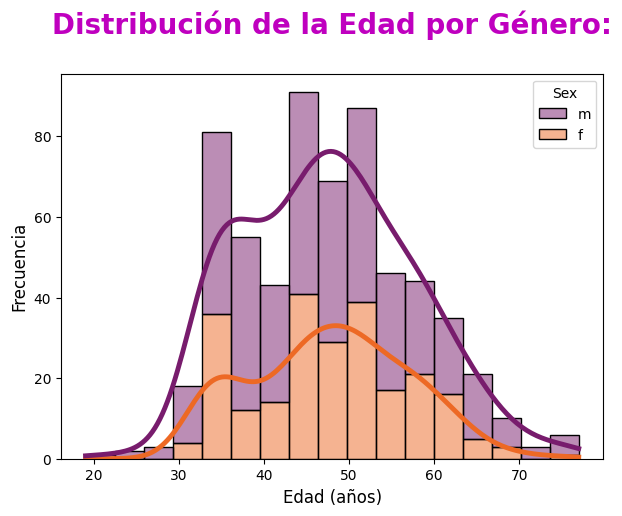

In [ ]:
# Hacer un Gráfico de la distribución de edades por género con KDE = Sex

plt.figure(figsize=(7, 5))
sns.histplot(data=data, x='Age', hue='Sex', kde=True, palette='inferno', multiple='stack', line_kws={'linewidth': 3.5})

# Títulos y etiquetas
plt.title('Distribución de la Edad por Género:\n', fontsize = 20, fontweight = 'bold', color = 'm')
plt.xlabel('Edad (años)', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.show()


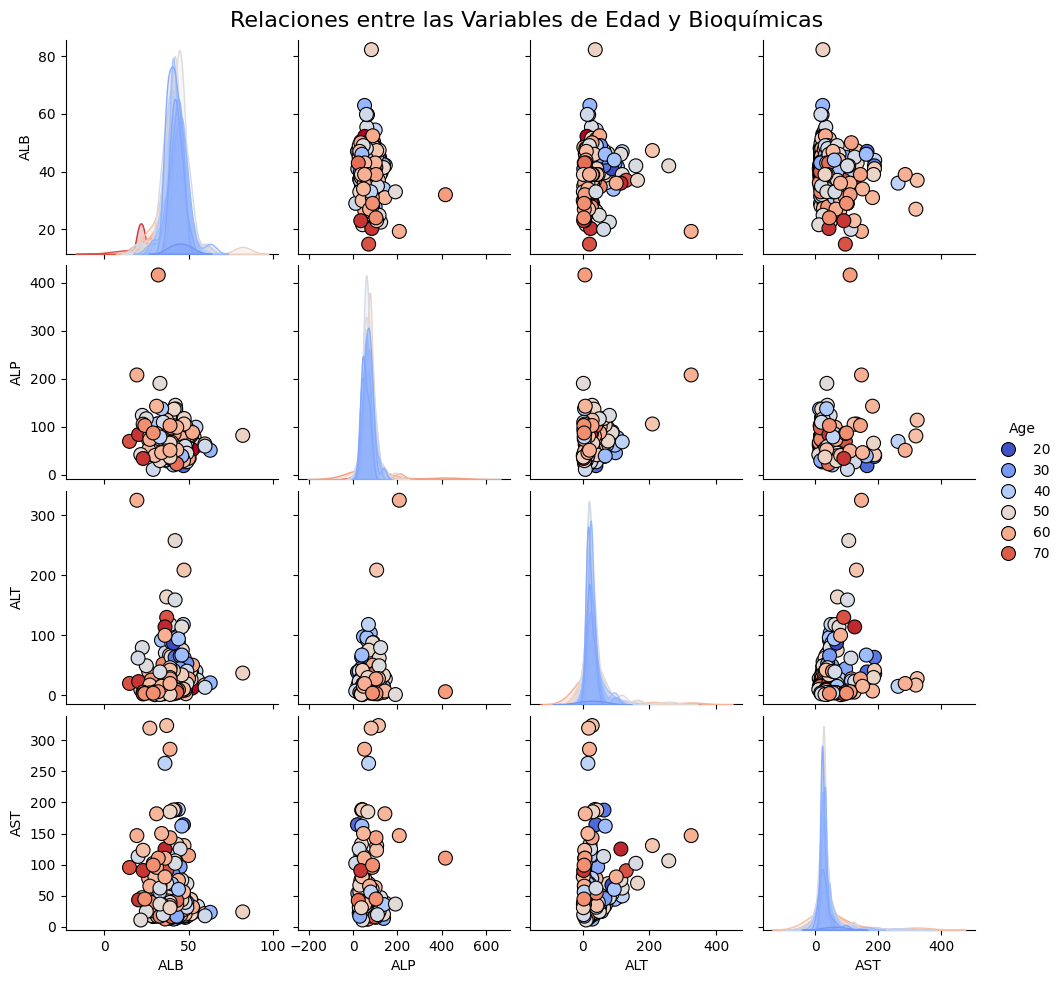

In [ ]:
# Crear el pairplot con las columnas: 'Age', 'ALB', 'ALP', 'ALT', 'AST'

sns.pairplot(data[['Age', 'ALB', 'ALP', 'ALT', 'AST']],
             hue='Age',  # Usamos Age para diferenciar los puntos por color
             palette='coolwarm',  # Paleta de colores atractivo
             markers='o',  # Marca los puntos con círculos
             plot_kws={'s': 100, 'edgecolor': 'k'},  # Tamaño de los puntos y borde negro
             height=2.5,  # Ajustamos el tamaño de cada gráfico
             diag_kind='kde')  # Usamos KDE para las distribuciones diagonales
             #corner=True)  # Muestra solo la parte inferior de la matriz para más claridad

# Mejoramos el título y las etiquetas
plt.suptitle('Relaciones entre las Variables de Edad y Bioquímicas', fontsize=16)
plt.subplots_adjust(top=0.95)  # Ajuste del título para que no se solape

# Mostrar el gráfico
plt.show()


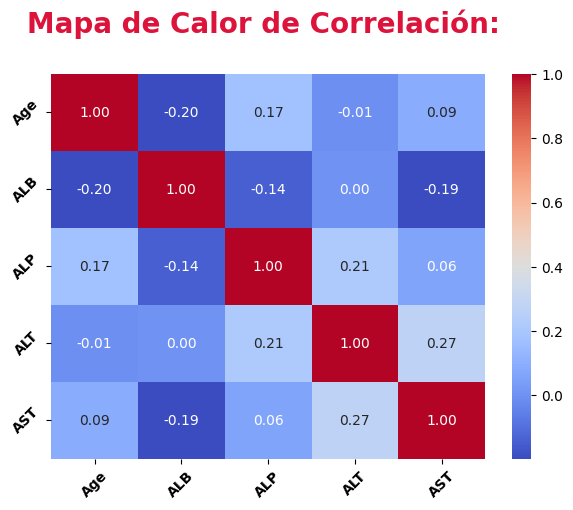

In [ ]:
# HAcer un gráfico de correlaciones con heatmap de las columnas 'Age', 'ALB', 'ALP', 'ALT', 'AST'

plt.figure(figsize=(7, 5))
corr = data[['Age', 'ALB', 'ALP', 'ALT', 'AST']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación: \n', fontsize = 20, fontweight = 'bold', color = 'crimson', loc = 'center')
plt.xticks(fontsize=10, fontweight='bold', rotation=45)
plt.yticks(fontsize=10, fontweight='bold', rotation=45)
plt.show()


## 5. $\text{Aplicación de K-Means Clustering}$

###   Selección del Número de Clústeres con Método Elbow

Text(0.5, 1.0, 'Gráfico del Codo')

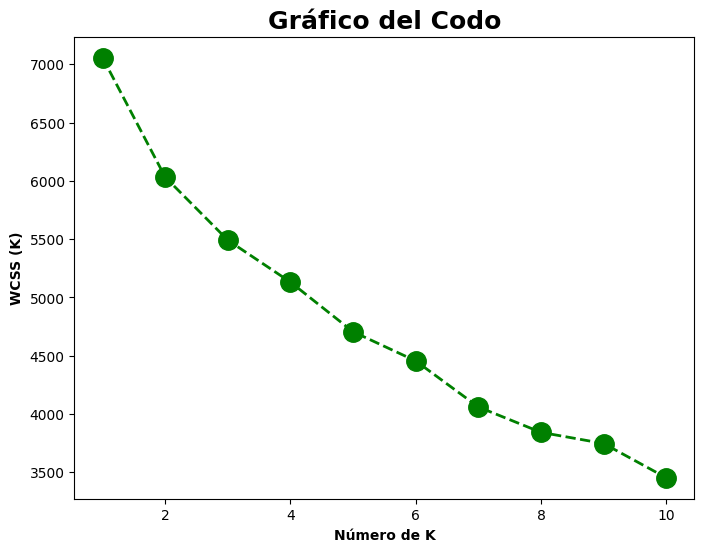

In [ ]:
# Método del codo

WCSS = [] # se iniciliza la lista donde se almacena WCSS(k)

for k in range(1,11):
  kpp = KMeans(n_clusters = k,      #instanciar el objeto KMeans con el número de cluster(IMPERATIVO)
               init = 'k-means++',
               random_state = 47, n_init = 'auto')
  kpp.fit(X_sc)
  WCSS.append(kpp.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1,11), WCSS, 'go--', linewidth=2, markersize=14)
plt.xlabel('Número de K', fontweight='bold')
plt.ylabel('WCSS (K)', fontweight='bold')
plt.title('Gráfico del Codo', fontsize=18, fontweight='bold')

###   Entrenamiento del Modelo K-Means

#### Con cluster = 9

In [ ]:
k_final = KMeans(n_clusters = 9,
                 init = 'k-means++',
                 random_state = 47, n_init = 'auto') # se instancia el objeto

etiqueta_cluster = k_final.fit_predict(X_sc)  # se predice el modelo

print(etiqueta_cluster) # se imprime

[1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 8 0
 0 0 0 0 0 1 0 0 8 0 0 0 0 0 0 0 1 0 0 1 8 0 1 0 0 0 0 8 8 0 0 0 0 0 8 0 8
 1 0 1 8 8 0 0 8 0 1 8 0 1 0 4 8 0 8 0 0 1 0 1 0 8 0 0 1 0 0 0 0 0 0 8 0 8
 0 0 4 8 1 8 1 0 0 0 0 0 8 0 8 7 0 0 0 0 4 4 8 8 1 0 0 8 8 8 0 8 1 8 0 8 0
 1 1 4 0 0 8 0 0 0 0 4 0 8 0 0 0 1 0 8 0 8 0 0 1 0 0 8 0 3 4 3 1 4 0 8 8 8
 8 1 1 4 8 0 3 3 8 8 0 4 8 1 1 8 3 3 4 4 8 1 4 4 8 3 0 8 0 8 8 0 4 4 3 1 8
 3 8 4 3 8 3 3 3 1 8 4 3 4 8 3 3 8 8 4 8 4 4 4 1 4 3 2 3 3 4 4 3 4 4 3 3 4
 0 3 3 3 8 3 4 4 3 3 3 3 4 3 3 4 3 4 3 3 3 3 3 3 4 3 3 3 3 3 3 3 3 4 4 4 4
 4 4 3 3 3 4 3 3 4 4 4 4 3 3 4 3 2 3 4 2 3 3 1 0 1 0 1 1 0 1 1 1 0 0 0 1 1
 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1
 0 1 4 1 1 1 1 0 1 1 1 1 4 1 1 0 1 1 1 4 1 1 0 4 4 1 1 1 4 1 1 0 0 1 1 0 0
 1 1 4 1 4 1 1 1 4 1 4 0 1 1 1 1 1 4 1 4 1 0 1 1 8 1 4 1 4 1 1 4 4 4 1 1 1
 4 4 4 4 4 4 4 1 3 1 1 4 1 4 4 4 3 1 8 4 4 4 1 3 4 3 4 4 4 1 4 3 4 4 3 1 4
 3 1 2 4 4 4 3 4 1 4 4 4 

### Visualización de los Clústeres

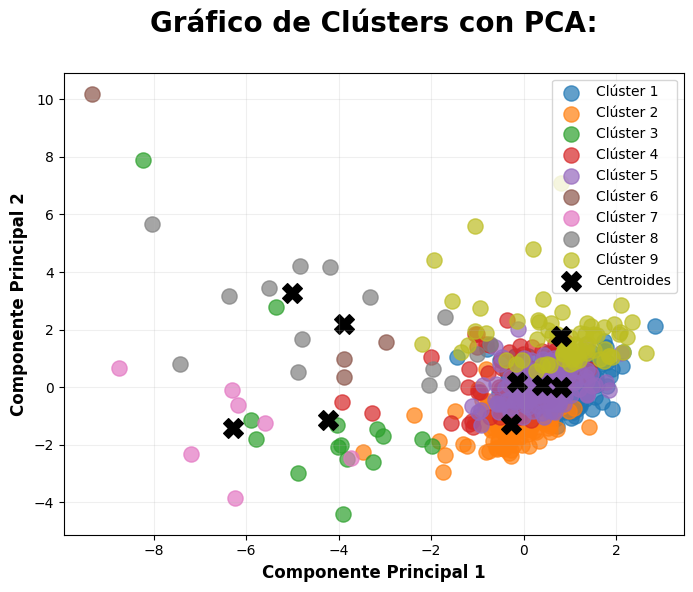

In [ ]:
# Reducción a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

# Gráfica de clústeres
plt.figure(figsize=(8, 6))

for i in range(9):  # Para cada clúster (0 a 8)
    plt.scatter(X_pca[etiqueta_cluster == i, 0],  # Dimensión PCA 1
                X_pca[etiqueta_cluster == i, 1],  # Dimensión PCA 2
                label=f'Clúster {i+1}', s=120, alpha = 0.7)

# Centroides en en el nuevo PCA
centroids_pca = pca.transform(k_final.cluster_centers_)  # Transformar los centroides
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', label='Centroides', s=200, marker='X')

# Etiquetas y estilo
plt.xlabel('Componente Principal 1', fontsize=12, fontweight='bold')
plt.ylabel('Componente Principal 2', fontsize=12, fontweight='bold')
plt.title('Gráfico de Clústers con PCA:\n', fontsize=20, fontweight='bold')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## Método de las siluetas

Para K=2, Coeficiente de Silueta = 0.5806
Para K=3, Coeficiente de Silueta = 0.1256
Para K=4, Coeficiente de Silueta = 0.1172
Para K=5, Coeficiente de Silueta = 0.1252
Para K=6, Coeficiente de Silueta = 0.1175
Para K=7, Coeficiente de Silueta = 0.1221
Para K=8, Coeficiente de Silueta = 0.1188
Para K=9, Coeficiente de Silueta = 0.1178
Para K=10, Coeficiente de Silueta = 0.1194


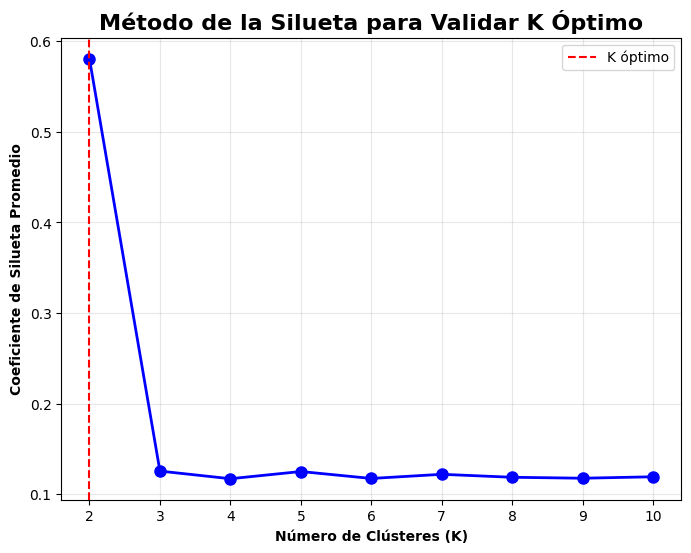

In [ ]:
# Método de la Silueta para validar K óptimo
silhouette_scores = []

# Rango de K a evaluar (de 2 a 10 clusters)
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=47, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_sc)
    silhouette_avg = silhouette_score(X_sc, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para K={k}, Coeficiente de Silueta = {silhouette_avg:.4f}")

# Gráfico del Coeficiente de Silueta
plt.figure(figsize=(8, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clústeres (K)', fontweight='bold')
plt.ylabel('Coeficiente de Silueta Promedio', fontweight='bold')
plt.title('Método de la Silueta para Validar K Óptimo', fontsize=16, fontweight='bold')
plt.axvline(x=np.argmax(silhouette_scores)+2, color='r', linestyle='--', label='K óptimo')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Con cluster = 2

In [ ]:
k_final2 = KMeans(n_clusters = 2,
                 init = 'k-means++',
                 random_state = 47, n_init = 'auto') # se instancia el objeto

etiqueta_cluster2 = k_final2.fit_predict(X_sc)  # se predice el modelo

print(etiqueta_cluster2) # se imprime

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

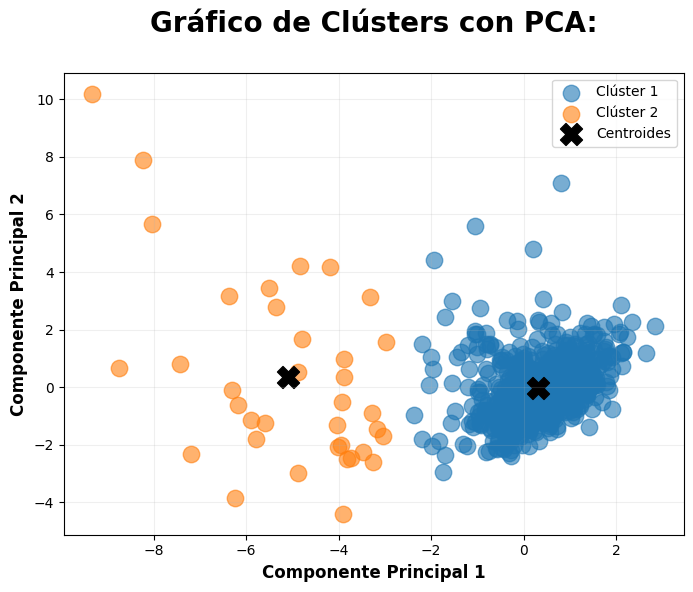

In [ ]:
# Reducción a 2 dimensiones
pca = PCA(n_components=2)
X_pca2 = pca.fit_transform(X_sc)

# Transformar los centroides del modelo actual (k_final2) usando el mismo PCA
centroids_pca2 = pca.transform(k_final2.cluster_centers_)

# Gráfica de clústeres
plt.figure(figsize=(8, 6))

for i in range(2):  # Para cada clúster (0 a 8)
    plt.scatter(X_pca2[etiqueta_cluster2 == i, 0],  # Dimensión PCA 1
                X_pca2[etiqueta_cluster2 == i, 1],  # Dimensión PCA 2
                label=f'Clúster {i+1}', s=140, alpha = 0.6)

# Centroides en en el nuevo PCA
plt.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1], c='black', label='Centroides', s=250, marker='X')

# Etiquetas y estilo
plt.xlabel('Componente Principal 1', fontsize=12, fontweight='bold')
plt.ylabel('Componente Principal 2', fontsize=12, fontweight='bold')
plt.title('Gráfico de Clústers con PCA:\n', fontsize=20, fontweight='bold')
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## USando Gap Static

In [ ]:
df2 = pd.DataFrame(X_sc)
#df2['cluster'] = etiqueta_cluster2
df2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,-1.533616,-0.540647,-0.616004,-0.816054,-0.383693,-0.198236,-0.574734,-1.904676,0.49707,-0.502286,-0.564372
1,0.0,1.0,-1.533616,-0.540647,0.078682,-0.410992,-0.305057,-0.381375,1.349161,-0.506078,-0.14659,-0.438203,0.826102
2,0.0,1.0,-1.533616,0.91485,0.250402,0.304747,0.538767,-0.269457,0.291926,-0.149747,0.094783,-0.115957,1.345212
3,0.0,1.0,-1.533616,0.273738,-0.635517,0.08452,-0.368571,0.381706,-0.393234,-0.559528,-0.025903,-0.104971,0.677784
4,0.0,1.0,-1.533616,-0.419356,0.226986,0.163172,-0.302033,-0.091404,0.432588,-0.933675,-0.106361,-0.176378,-0.619991


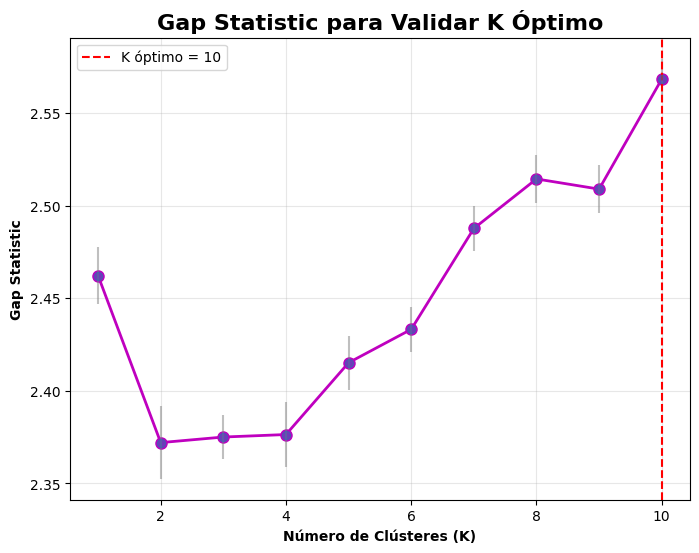

In [ ]:
# Implementación manual del Gap Statistic
def compute_gap_statistic(data, K_max=10, n_bootstrap=50):
    gaps = []
    s_k = []

    for k in range(1, K_max + 1):
        # Cluster datos reales
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=47, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        inertia_real = kmeans.inertia_

        # Generar datos de referencia uniformes
        min_vals = np.min(data, axis=0)
        max_vals = np.max(data, axis=0)
        inertia_ref = []

        for _ in range(n_bootstrap):
            ref_data = np.random.uniform(low=min_vals, high=max_vals, size=data.shape)
            kmeans_ref = KMeans(n_clusters=k, init='k-means++', random_state=47, n_init='auto')
            kmeans_ref.fit(ref_data)
            inertia_ref.append(kmeans_ref.inertia_)

        # Calcular Gap
        gap = np.log(np.mean(inertia_ref)) - np.log(inertia_real)
        gaps.append(gap)
        s_k.append(np.std(np.log(inertia_ref)) * np.sqrt(1 + 1/n_bootstrap))

    return gaps, s_k

# Calcular Gap para K=1 a 10
gaps, s_k = compute_gap_statistic(df2, K_max=10)
optimal_k = np.argmax(gaps) + 1  # +1 porque K empieza en 1

# Gráfico del Gap Statistic
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), gaps, 'mo-', linewidth=2, markersize=8)
plt.errorbar(range(1,11), gaps, yerr=s_k, fmt='o', ecolor='gray', alpha=0.5)
plt.xlabel('Número de Clústeres (K)', fontweight='bold')
plt.ylabel('Gap Statistic', fontweight='bold')
plt.title('Gap Statistic para Validar K Óptimo', fontsize=16, fontweight='bold')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'K óptimo = {optimal_k}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Usando Índice de Davies-Bouldin

Para K=2, Índice de Davies-Bouldin = 1.7033
Para K=3, Índice de Davies-Bouldin = 1.9778
Para K=4, Índice de Davies-Bouldin = 1.9491
Para K=5, Índice de Davies-Bouldin = 1.7742
Para K=6, Índice de Davies-Bouldin = 1.7725
Para K=7, Índice de Davies-Bouldin = 1.5995
Para K=8, Índice de Davies-Bouldin = 1.6221
Para K=9, Índice de Davies-Bouldin = 1.6404
Para K=10, Índice de Davies-Bouldin = 1.4663


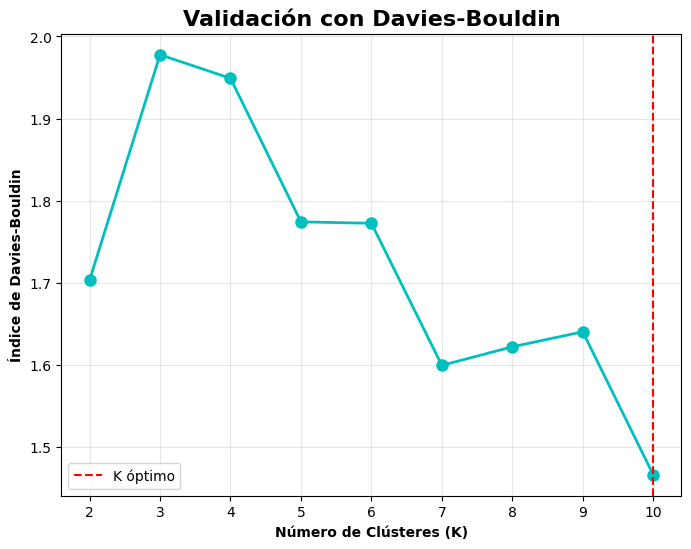

In [ ]:
from sklearn.metrics import davies_bouldin_score

# Cálculo del Índice de Davies-Bouldin
db_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=47, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_sc)
    db_score = davies_bouldin_score(X_sc, cluster_labels)
    db_scores.append(db_score)
    print(f"Para K={k}, Índice de Davies-Bouldin = {db_score:.4f}")

# Gráfico del Índice
plt.figure(figsize=(8, 6))
plt.plot(K_range, db_scores, 'co-', linewidth=2, markersize=8)
plt.xlabel('Número de Clústeres (K)', fontweight='bold')
plt.ylabel('Índice de Davies-Bouldin', fontweight='bold')
plt.title('Validación con Davies-Bouldin', fontsize=16, fontweight='bold')
plt.axvline(x=np.argmin(db_scores)+2, color='r', linestyle='--', label='K óptimo')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. $\text{Aplicación de Clustering Jerárquico}$

###  Dendrograma para Determinar el Número de Clústere

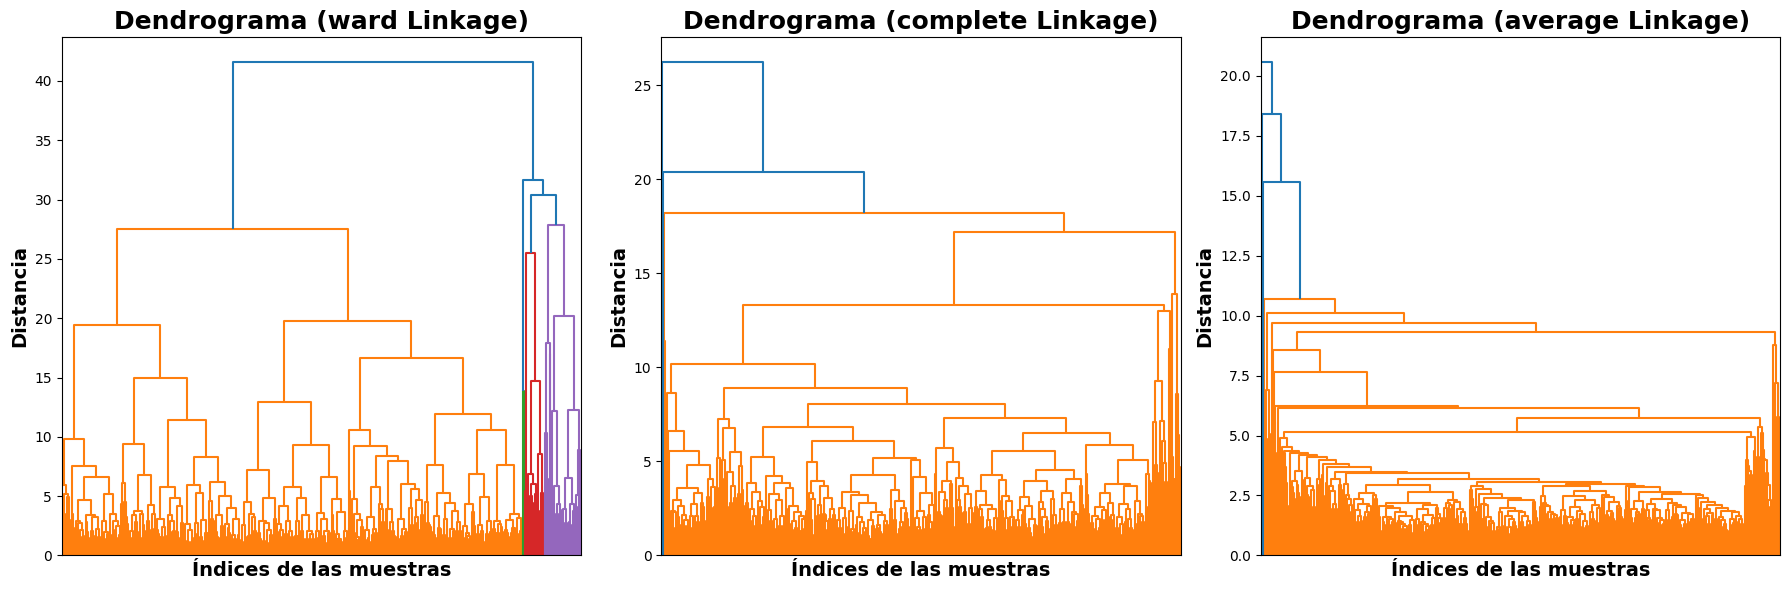

In [ ]:
# Crear un dendograma con linkage: ward y average

# Calcular las distancias entre las muestras usando diferentes enlaces
linkage_methods = ['ward', 'complete', 'average'] #Se eligen ward, complete y average.

plt.figure(figsize=(18, 6))

# Iterar sobre los diferentes enlaces
for i, linkage_method in enumerate(linkage_methods, start = 1):
    plt.subplot(1, 3, i)

    # Calcular las distancias usando el método de enlace específico
    dendrogram = sch.dendrogram(sch.linkage(X_sc, method=linkage_method))

     # Personalizar los ejes
    plt.title(f'Dendrograma ({linkage_method} Linkage)', fontsize=18, fontweight='bold')
    plt.xlabel('Índices de las muestras', fontsize=14, fontweight='bold')
    plt.ylabel('Distancia', fontsize=14, fontweight='bold')
    plt.xticks([]) # para que no s evean los valores en x
    plt.yticks(fontsize=10)
    plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# Calcula el linkage
Z = linkage(X_sc, method='ward')

# Calcular el número óptimo de clústeres basado en una distancia máxima
max_dist = 25  # Ajusta según la observación visual
clusters = fcluster(Z, max_dist, criterion='distance')
print("Número de clusters según distancia máxima:", len(np.unique(clusters)))

Número de clusters según distancia máxima: 7


### Entrenamiento y Visualización de Clústeres

In [ ]:
# Ahora utilice la clase AgglomerativeClustering de scikit-learn para entrenar sus datos
# con los clústers que le arrojo el dendograma

número_clusters = 7
agglomeración = AgglomerativeClustering(n_clusters = número_clusters) # Se instancia el modelo

# Entrenar el modelo utilizando tus datos
clusters2 = agglomeración.fit_predict(X_sc)

# Visualizar los resultados
print("Asignación de clusters: ")
print(clusters2)

Asignación de clusters: 
[1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 3 1 1 1 1 1 1 1 2 1
 1 1 1 2 1 1 1 1 0 1 2 1 1 1 1 1 1 2 2 1 2 1 1 2 1 1 1 0 0 1 1 1 1 1 2 1 1
 1 1 1 2 0 1 1 2 2 1 0 1 1 1 1 2 1 2 2 1 1 2 1 1 2 1 2 1 1 1 1 1 1 1 1 2 1
 2 1 1 0 1 2 1 1 1 1 1 1 2 1 2 0 1 1 1 2 1 1 2 2 1 2 1 2 2 0 1 2 1 2 1 2 1
 1 1 1 1 1 2 1 1 0 1 1 2 2 1 1 2 1 1 2 1 2 1 1 1 2 1 2 1 1 2 1 1 2 2 2 2 2
 2 1 1 1 2 1 1 1 2 0 2 1 2 1 1 2 1 1 1 1 2 1 1 2 2 2 2 2 1 2 2 1 1 2 2 1 2
 1 2 2 1 2 0 1 2 1 2 2 2 1 2 2 2 2 2 1 2 2 2 2 1 2 2 1 1 1 2 2 1 1 2 1 1 2
 1 2 1 2 2 2 1 2 2 2 1 1 2 2 2 1 1 2 1 1 1 2 2 1 2 2 1 1 2 1 2 2 2 2 2 2 2
 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 1 3 1 2 3 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 2 1 1 1 1 1
 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 1 2 1 2 1 1 1 1 2 1 2 1 1 1 1 2 1 2 1 1 1
 1 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 1 2 1 2 1 1 1 2 2 2 2 2 1 2 2 2 2 2 2 1


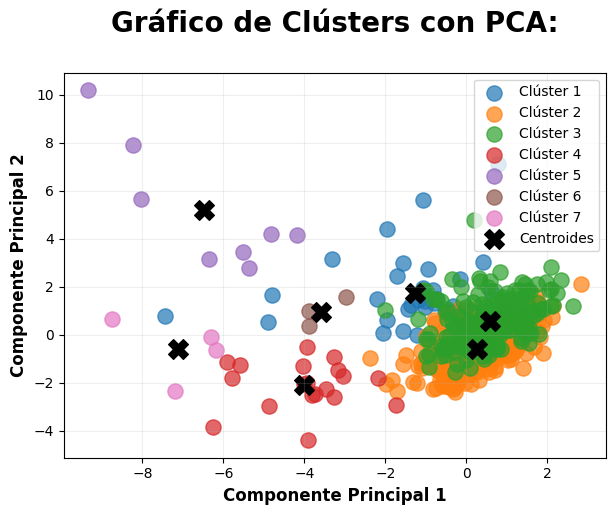

In [ ]:
# Reducción a 2 dimensiones con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

# Gráfica de clústeres
plt.figure(figsize=(7, 5))

for i in range(7):  # Para cada clúster (0 a 6)
    plt.scatter(X_pca[clusters2 == i, 0],  # Dimensión PCA 1
                X_pca[clusters2 == i, 1],  # Dimensión PCA 2
                label=f'Clúster {i+1}', s=120, alpha=0.7)

# Calcular los centroides manualmente
centroids = []
for cluster_id in range(número_clusters):
    # Filtrar los puntos que pertenecen al clúster actual
    cluster_points = X_sc[clusters2 == cluster_id]
    # Calcular el centroide promedio
    centroid = np.mean(cluster_points, axis=0)
    centroids.append(centroid)

# Transformar los centroides al espacio PCA
centroids_pca = pca.transform(np.array(centroids))

# Graficar los centroides
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', label='Centroides', s=200, marker='X')

# Etiquetas y estilo
plt.xlabel('Componente Principal 1', fontsize=12, fontweight='bold')
plt.ylabel('Componente Principal 2', fontsize=12, fontweight='bold')
plt.title('Gráfico de Clústers con PCA:\n', fontsize=20, fontweight='bold')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 7. $\text{Comparación y Conclusiones}$

Compare visualmente cuál modelo es mejor

### Interpretación de Resultados Contradictorios
- **Método del Codo (K=9):** Prioriza reducir la varianza interna, ideal para granularidad extrema (ej: detección de subgrupos médicos).
- **Silueta/Davies-Bouldin (K=3):** Busca equilibrio entre cohesión y separación, útil para agrupaciones generales.
- **Gap Statistic (K=4):** Compara con datos aleatorios, evitando sobreajuste.
- **Conclusión:** No hay un K "correcto". Depende del objetivo:
  - **K pequeño:** Para categorías amplias (ej: etapas de enfermedad).
  - **K grande:** Para análisis detallado (ej: subtipos de pacientes).

# Diferencias Detalladas entre Clustering Jerárquico, Método del Codo y Método de las Siluetas

## 1. Clustering Jerárquico
**Objetivo:** Construir una estructura de árbol (dendrograma) que represente relaciones jerárquicas entre los datos.

**Tipos:**
- **Aglomerativo:** Fusión progresiva de clusters (de abajo hacia arriba).
- **Divisivo:** División progresiva de clusters (de arriba hacia abajo).

**Cálculo Detallado:**

**Inicialización:** Cada punto es un cluster individual.

**Matriz de Distancia:** Se calcula una matriz de distancias entre todos los pares de puntos (ej: distancia euclidiana).

**Enlace (Linkage):**
- **Enlace Simple:** Distancia mínima entre clusters (más cercano):
  $$ d(C_1, C_2) = \min_{a \in C_1, b \in C_2} d(a, b) $$
- **Enlace Completo:** Distancia máxima entre clusters (más lejano):
  $$ d(C_1, C_2) = \max_{a \in C_1, b \in C_2} d(a, b) $$
- **Enlace Promedio:** Distancia promedio entre clusters:
  $$ d(C_1, C_2) = \frac{1}{|C_1| |C_2|} \sum_{a \in C_1} \sum_{b \in C_2} d(a, b) $$
- **Método de Ward:** Minimiza la varianza total al fusionar clusters:
  $$ d(C_1, C_2) = \text{Incremento en la suma de cuadrados intra-cluster} $$

**Fusión/División:** En cada paso, se fusionan los dos clusters más cercanos (aglomerativo) o se divide el cluster menos coherente (divisivo).

**Dendrograma:** Representación gráfica donde la altura vertical indica la distancia a la que se fusionan los clusters.

**Ventajas:**
- No requiere especificar el número de clusters a priori.
- Útil para visualizar relaciones jerárquicas.

**Desventajas:**
- Costo computacional alto ($O(n^3)$ para aglomerativo).
- Sensible a outliers.

---



## 2. Método del Codo (Elbow Method)
**Objetivo:** Determinar el número óptimo de clusters ($K$) en algoritmos como K-Means.

**Ventajas:**  
- Simple de implementar.  
- Útil cuando la estructura de clusters es clara.  

**Desventajas:**  
- Subjetivo: El "codo" no siempre es evidente.  
- No funciona bien en datos sin estructura clara.  

---

## 3. Método de las Siluetas  
**Objetivo:** Evaluar la calidad de los clusters midiendo cohesión y separación.  

**Cálculo Detallado:**  

**Cohesión ($a_i$):** Distancia promedio de un punto $i$ a todos los demás puntos en su cluster:  
$$ a_i = \frac{1}{|C_i| - 1} \sum_{j \in C_i, j \neq i} d(i, j) $$  

**Separación ($b_i$):** Distancia promedio de $i$ al cluster más cercano (no propio):  
$$ b_i = \min_{C_k \neq C_i} \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j) $$  

**Puntuación de Silueta ($s_i$):**  
$$ s_i = \frac{b_i - a_i}{\max(a_i, b_i)} $$  
Donde $s_i \in [-1, 1]$:  
- $s_i \approx 1$: Punto bien agrupado.  
- $s_i \approx 0$: Punto entre dos clusters.  
- $s_i \approx -1$: Punto mal agrupado.  

**Coeficiente de Silueta Promedio:**  
$$ \text{Silhouette Score} = \frac{1}{n} \sum_{i=1}^n s_i $$  

**Ventajas:**  
- Cuantifica la calidad de los clusters.  
- Funciona bien incluso sin un "codo" claro.  

**Desventajas:**  
- Costoso computacionalmente ($O(n^2)$).  
- No siempre detecta clusters no convexos.  

---

## Comparación Final  

| **Aspecto**          | **Clustering Jerárquico**       | **Método del Codo**            | **Método de las Siluetas**       |  
|----------------------|----------------------------------|---------------------------------|-----------------------------------|  
| **Objetivo**         | Estructura jerárquica           | Encontrar $K$ óptimo           | Evaluar calidad de clusters       |  
| **Cálculo Principal**| Matriz de distancias y enlace   | WCSS vs $K$                     | Cohesión y separación por punto   |  
| **Complejidad**      | $O(n^3)$ (aglomerativo)         | $O(n \cdot K_{\text{max}})$    | $O(n^2)$                          |  
| **Uso de $K$**       | No requiere $K$ inicial         | Requiere especificar $K$       | Requiere especificar $K$          |  
| **Mejor Caso de Uso**| Datos con jerarquía natural     | Datos con estructura clara     | Validación de clusters            |  